+ MSSV: 24280076  
+ Họ tên: Đặng Hoàng Khang

Yêu cầu: Sinh viên thực hiện bài tập với ba vai trò như sau:

- Vai trò Data Engineer: Xử lý các file dữ liệu đầu vào, chuẩn hoá và làm sạch dữ liệu, sau đó tạo ra một file dữ liệu sạch dùng chung.
- Vai trò Data Analyst: Sử dụng tập dữ liệu sạch bởi data engineer, hãy trực quan hoá dữ liệu bằng các biểu đồ, khám phá dữ liệu và trả lời các câu hỏi đã nêu ở Mục 2. Data Analytics.
- Vai trò Data Scientist: Xây dựng mô hình regression để dự đoán Profit và đưa ra nhận xét về kết quả.

In [329]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Data Engineer

### 1.1 Data preprocessing: Orders



In [330]:
df_orders_Q1 = pd.read_csv('lab03_Orders_Q1.csv')

In [331]:
df_orders_Q1.head()

,Order_ID,Order_Date,Order_Priority,Customer_ID,Industry_name,Province,Region,Channel,Product_ID,Sales,Quantity,Unit_Price,Discount,Profit,Returned_Reason
0,HC-2011-103800,1/4/24,Medium,DP-13000,Thiết bị gia dụng,Hồ Chí Minh,Miền Đông Nam Bộ,Store,OFF-PA-10000174,16.448,2.0,8.224,0.2,5.5512,No reason
1,NA-2011-112326,2024.01.05,Medium,PO-19195,Thiết bị gia dụng,Nghệ An,Miền Trung,Online,OFF-LA-10003223,11.784,3.0,3.928,0.2,4.2717,""""""
2,NA-2011-112326,1/5/24,Low,PO-19195,Thiết bị gia dụng,Nghệ An,Miền Trung,Online,OFF-ST-10002743,272.736,3.0,90.912,0.2,-64.7748,""""""
3,NA-2011-112326,1/5/24,Low,PO-19195,Thiết bị gia dụng,Nghệ An,Miền Đông Nam Bộ,Online,OFF-BI-10004094,3.540,2.0,NaN,0.8,-5.4870,NaN
4,TN-2011-141817,1/6/24,Medium,MB-18085,Thiết bị gia dụng,Tây Ninh,Miền Đông Nam Bộ,Store,OFF-AR-10003478,19.536,3.0,6.512,0.2,4.8840,NaN


In [332]:
df_orders_Q1.info()

<class 'pandas.DataFrame'>
RangeIndex: 281 entries, 0 to 280
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order_ID         281 non-null    str    
 1   Order_Date       281 non-null    str    
 2   Order_Priority   281 non-null    str    
 3   Customer_ID      281 non-null    str    
 4   Industry_name    281 non-null    str    
 5   Province         279 non-null    str    
 6   Region           279 non-null    str    
 7   Channel          279 non-null    str    
 8   Product_ID       279 non-null    str    
 9   Sales            279 non-null    float64
 10  Quantity         279 non-null    float64
 11  Unit_Price       275 non-null    float64
 12  Discount         259 non-null    float64
 13  Profit           279 non-null    float64
 14  Returned_Reason  10 non-null     str    
dtypes: float64(5), str(10)
memory usage: 33.1 KB


In [333]:
df_orders_Q2 = pd.read_csv('lab03_Orders_Q2.csv')

In [334]:
df_orders_Q2.head()

,Order_ID,Order_Date,Order_Priority,Customer_ID,Industry_name,Province,Region,Channel,Product_ID,Sales,Quantity,Price,Discount,Profit,Returned_Reason,Notes
0,ĐN-2011-107181,5/12/24,Medium,DB-13270,Thiết bị gia dụng,Đà Nẵng,Miền Trung,Store,OFF-BI-10004230,82.896,3.0,27.632,0.2,29.0136,NaN,NaN
1,TG-2011-157021,4/1/24,Medium,KM-16720,Thiết bị gia dụng,Tiền Giang,Miền Tây Nam Bộ,Store,OFF-LA-10002312,29.600,2.0,14.800,0.0,14.8000,NaN,NaN
2,TG-2011-157021,4/1/24,Medium,KM-16720,Thiết bị gia dụng,Tiền Giang,Miền Tây Nam Bộ,Store,OFF-BI-10000042,17.088,4.0,4.272,0.2,5.5536,NaN,NaN
3,TG-2011-138359,4/1/24,Medium,KH-16330,Thiết bị gia dụng,Tiền Giang,Miền Tây Nam Bộ,Agent,OFF-ST-10000636,66.960,4.0,16.740,0.0,2.6784,NaN,NaN
4,TG-2011-138359,4/1/24,Medium,KH-16330,Thiết bị gia dụng,Tiền Giang,Miền Tây Nam Bộ,Agent,OFF-BI-10000145,6.240,2.0,3.120,0.0,3.0576,NaN,NaN


In [335]:
df_orders_Q1.columns

Index(['Order_ID', 'Order_Date', 'Order_Priority', 'Customer_ID',
       'Industry_name', 'Province', 'Region', 'Channel', 'Product_ID', 'Sales',
       'Quantity', 'Unit_Price', 'Discount', 'Profit', 'Returned_Reason'],
      dtype='str')

In [336]:
df_orders_Q2.columns

Index(['Order_ID', 'Order_Date', 'Order_Priority', 'Customer_ID',
       'Industry_name', 'Province', 'Region', 'Channel', 'Product_ID', 'Sales',
       'Quantity', 'Price', 'Discount', 'Profit', 'Returned_Reason', 'Notes'],
      dtype='str')

In [337]:
# Rename Price thành Unit_Price
df_orders_Q2 = df_orders_Q2.rename(columns={'Price':"Unit_Price"})

In [338]:
df_orders_Q2.head()

,Order_ID,Order_Date,Order_Priority,Customer_ID,Industry_name,Province,Region,Channel,Product_ID,Sales,Quantity,Unit_Price,Discount,Profit,Returned_Reason,Notes
0,ĐN-2011-107181,5/12/24,Medium,DB-13270,Thiết bị gia dụng,Đà Nẵng,Miền Trung,Store,OFF-BI-10004230,82.896,3.0,27.632,0.2,29.0136,NaN,NaN
1,TG-2011-157021,4/1/24,Medium,KM-16720,Thiết bị gia dụng,Tiền Giang,Miền Tây Nam Bộ,Store,OFF-LA-10002312,29.600,2.0,14.800,0.0,14.8000,NaN,NaN
2,TG-2011-157021,4/1/24,Medium,KM-16720,Thiết bị gia dụng,Tiền Giang,Miền Tây Nam Bộ,Store,OFF-BI-10000042,17.088,4.0,4.272,0.2,5.5536,NaN,NaN
3,TG-2011-138359,4/1/24,Medium,KH-16330,Thiết bị gia dụng,Tiền Giang,Miền Tây Nam Bộ,Agent,OFF-ST-10000636,66.960,4.0,16.740,0.0,2.6784,NaN,NaN
4,TG-2011-138359,4/1/24,Medium,KH-16330,Thiết bị gia dụng,Tiền Giang,Miền Tây Nam Bộ,Agent,OFF-BI-10000145,6.240,2.0,3.120,0.0,3.0576,NaN,NaN


In [339]:
cols = df_orders_Q1.columns.to_list()

In [340]:
cols

['Order_ID',
 'Order_Date',
 'Order_Priority',
 'Customer_ID',
 'Industry_name',
 'Province',
 'Region',
 'Channel',
 'Product_ID',
 'Sales',
 'Quantity',
 'Unit_Price',
 'Discount',
 'Profit',
 'Returned_Reason']

In [341]:
df_orders_Q2 = df_orders_Q2[cols]

In [342]:
df_orders_Q2

,Order_ID,Order_Date,Order_Priority,Customer_ID,Industry_name,Province,Region,Channel,Product_ID,Sales,Quantity,Unit_Price,Discount,Profit,Returned_Reason
0,ĐN-2011-107181,5/12/24,Medium,DB-13270,Thiết bị gia dụng,Đà Nẵng,Miền Trung,Store,OFF-BI-10004230,82.896,3.0,27.632,0.2,29.0136,NaN
1,TG-2011-157021,4/1/24,Medium,KM-16720,Thiết bị gia dụng,Tiền Giang,Miền Tây Nam Bộ,Store,OFF-LA-10002312,29.600,2.0,14.800,0.0,14.8000,NaN
2,TG-2011-157021,4/1/24,Medium,KM-16720,Thiết bị gia dụng,Tiền Giang,Miền Tây Nam Bộ,Store,OFF-BI-10000042,17.088,4.0,4.272,0.2,5.5536,NaN
3,TG-2011-138359,4/1/24,Medium,KH-16330,Thiết bị gia dụng,Tiền Giang,Miền Tây Nam Bộ,Agent,OFF-ST-10000636,66.960,4.0,16.740,0.0,2.6784,NaN
4,TG-2011-138359,4/1/24,Medium,KH-16330,Thiết bị gia dụng,Tiền Giang,Miền Tây Nam Bộ,Agent,OFF-BI-10000145,6.240,2.0,3.120,0.0,3.0576,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
217,HT-2011-127166,5/21/24,Medium,KH-16360,Thiết bị gia dụng,Hà Tỉnh,Miền Trung,Agent,OFF-PA-10001560,4.832,1.0,4.832,0.2,1.6308,NaN
218,HT-2011-127166,5/21/24,Low,KH-16360,Thiết bị gia dụng,Hà Tỉnh,Miền Trung,Agent,OFF-BI-10000977,18.240,3.0,6.080,0.8,-31.0080,NaN
219,HT-2011-127166,5/21/24,Low,KH-16360,Thiết bị gia dụng,Hà Tỉnh,Miền Trung,Agent,OFF-BI-10000977,18.240,3.0,6.080,0.8,-31.0080,NaN
220,HC-2011-130673,5/20/24,Low,MC-17590,Thiết bị gia dụng,Hồ Chí Minh,Miền Đông Nam Bộ,Agent,OFF-ST-10000636,66.960,5.0,13.392,0.2,-13.3920,NaN


In [343]:
# union 2 files
df_orders = pd.concat([df_orders_Q1, df_orders_Q2], ignore_index=True)
df_orders.head()

,Order_ID,Order_Date,Order_Priority,Customer_ID,Industry_name,Province,Region,Channel,Product_ID,Sales,Quantity,Unit_Price,Discount,Profit,Returned_Reason
0,HC-2011-103800,1/4/24,Medium,DP-13000,Thiết bị gia dụng,Hồ Chí Minh,Miền Đông Nam Bộ,Store,OFF-PA-10000174,16.448,2.0,8.224,0.2,5.5512,No reason
1,NA-2011-112326,2024.01.05,Medium,PO-19195,Thiết bị gia dụng,Nghệ An,Miền Trung,Online,OFF-LA-10003223,11.784,3.0,3.928,0.2,4.2717,""""""
2,NA-2011-112326,1/5/24,Low,PO-19195,Thiết bị gia dụng,Nghệ An,Miền Trung,Online,OFF-ST-10002743,272.736,3.0,90.912,0.2,-64.7748,""""""
3,NA-2011-112326,1/5/24,Low,PO-19195,Thiết bị gia dụng,Nghệ An,Miền Đông Nam Bộ,Online,OFF-BI-10004094,3.540,2.0,NaN,0.8,-5.4870,NaN
4,TN-2011-141817,1/6/24,Medium,MB-18085,Thiết bị gia dụng,Tây Ninh,Miền Đông Nam Bộ,Store,OFF-AR-10003478,19.536,3.0,6.512,0.2,4.8840,NaN


### 1.2 Data preprocessing: Customers

In [344]:
df_cus = pd.read_csv('lab03_CUS.csv')

In [345]:
df_cus.head()

,Customer_ID,Customer_Name,Customer_Segment,Birthday,Phone number,Province
0,DP-13000,Darren Tran,Consumer,1/11/70,909123123,Vĩnh Long
1,PO-19195,Phillina Ober,Home Office,9/14/84,909123124,TP HCM
2,MB-18085,Trần Nhiễm,Consumer,1/11/96,909123127,Bình Dương
3,LS-17230,Lycoris Saunders,Consumer,1/11/82,909123128,Vĩnh Phúc
4,JO-15145,Jack O'Briant,Corporate,1/11/80,909123129,Bình Dương


### 1.3. Join 2 df: Orders & Customers

### 1.3.1 Join 2 df với cùng tên cột join

In [346]:
df_orders_cus = df_orders.merge(df_cus, on="Customer_ID", how="inner")

In [347]:
df_orders_cus.head()

,Order_ID,Order_Date,Order_Priority,Customer_ID,Industry_name,Province,Region,Channel,Product_ID,Sales,Quantity,Unit_Price,Discount,Profit,Returned_Reason,Customer_Name,Customer_Segment,Birthday,Phone number,Province
0,HC-2011-103800,1/4/24,Medium,DP-13000,Thiết bị gia dụng,Hồ Chí Minh,Miền Đông Nam Bộ,Store,OFF-PA-10000174,16.448,2.0,8.224,0.2,5.5512,No reason,Darren Tran,Consumer,1/11/70,909123123,Vĩnh Long
1,NA-2011-112326,2024.01.05,Medium,PO-19195,Thiết bị gia dụng,Nghệ An,Miền Trung,Online,OFF-LA-10003223,11.784,3.0,3.928,0.2,4.2717,"""""",Phillina Ober,Home Office,9/14/84,909123124,TP HCM
2,NA-2011-112326,1/5/24,Low,PO-19195,Thiết bị gia dụng,Nghệ An,Miền Trung,Online,OFF-ST-10002743,272.736,3.0,90.912,0.2,-64.7748,"""""",Phillina Ober,Home Office,9/14/84,909123124,TP HCM
3,NA-2011-112326,1/5/24,Low,PO-19195,Thiết bị gia dụng,Nghệ An,Miền Đông Nam Bộ,Online,OFF-BI-10004094,3.540,2.0,NaN,0.8,-5.4870,NaN,Phillina Ober,Home Office,9/14/84,909123124,TP HCM
4,TN-2011-141817,1/6/24,Medium,MB-18085,Thiết bị gia dụng,Tây Ninh,Miền Đông Nam Bộ,Store,OFF-AR-10003478,19.536,3.0,6.512,0.2,4.8840,NaN,Trần Nhiễm,Consumer,1/11/96,909123127,Bình Dương


In [348]:
df_orders_cus = df_orders.merge(df_cus, on="Customer_ID", how="left")

In [349]:
df_orders_cus.head()

,Order_ID,Order_Date,Order_Priority,Customer_ID,Industry_name,Province,Region,Channel,Product_ID,Sales,Quantity,Unit_Price,Discount,Profit,Returned_Reason,Customer_Name,Customer_Segment,Birthday,Phone number,Province
0,HC-2011-103800,1/4/24,Medium,DP-13000,Thiết bị gia dụng,Hồ Chí Minh,Miền Đông Nam Bộ,Store,OFF-PA-10000174,16.448,2.0,8.224,0.2,5.5512,No reason,Darren Tran,Consumer,1/11/70,909123123.0,Vĩnh Long
1,NA-2011-112326,2024.01.05,Medium,PO-19195,Thiết bị gia dụng,Nghệ An,Miền Trung,Online,OFF-LA-10003223,11.784,3.0,3.928,0.2,4.2717,"""""",Phillina Ober,Home Office,9/14/84,909123124.0,TP HCM
2,NA-2011-112326,1/5/24,Low,PO-19195,Thiết bị gia dụng,Nghệ An,Miền Trung,Online,OFF-ST-10002743,272.736,3.0,90.912,0.2,-64.7748,"""""",Phillina Ober,Home Office,9/14/84,909123124.0,TP HCM
3,NA-2011-112326,1/5/24,Low,PO-19195,Thiết bị gia dụng,Nghệ An,Miền Đông Nam Bộ,Online,OFF-BI-10004094,3.540,2.0,NaN,0.8,-5.4870,NaN,Phillina Ober,Home Office,9/14/84,909123124.0,TP HCM
4,TN-2011-141817,1/6/24,Medium,MB-18085,Thiết bị gia dụng,Tây Ninh,Miền Đông Nam Bộ,Store,OFF-AR-10003478,19.536,3.0,6.512,0.2,4.8840,NaN,Trần Nhiễm,Consumer,1/11/96,909123127.0,Bình Dương


### 1.3.2 Join 2 df với cùng khác tên cột join

In [350]:
df_orders_cus_1 = df_orders.merge(df_cus, left_on="Customer_ID", right_on="Customer_ID", how="left")
df_orders_cus_1.head()

,Order_ID,Order_Date,Order_Priority,Customer_ID,Industry_name,Province,Region,Channel,Product_ID,Sales,Quantity,Unit_Price,Discount,Profit,Returned_Reason,Customer_Name,Customer_Segment,Birthday,Phone number,Province
0,HC-2011-103800,1/4/24,Medium,DP-13000,Thiết bị gia dụng,Hồ Chí Minh,Miền Đông Nam Bộ,Store,OFF-PA-10000174,16.448,2.0,8.224,0.2,5.5512,No reason,Darren Tran,Consumer,1/11/70,909123123.0,Vĩnh Long
1,NA-2011-112326,2024.01.05,Medium,PO-19195,Thiết bị gia dụng,Nghệ An,Miền Trung,Online,OFF-LA-10003223,11.784,3.0,3.928,0.2,4.2717,"""""",Phillina Ober,Home Office,9/14/84,909123124.0,TP HCM
2,NA-2011-112326,1/5/24,Low,PO-19195,Thiết bị gia dụng,Nghệ An,Miền Trung,Online,OFF-ST-10002743,272.736,3.0,90.912,0.2,-64.7748,"""""",Phillina Ober,Home Office,9/14/84,909123124.0,TP HCM
3,NA-2011-112326,1/5/24,Low,PO-19195,Thiết bị gia dụng,Nghệ An,Miền Đông Nam Bộ,Online,OFF-BI-10004094,3.540,2.0,NaN,0.8,-5.4870,NaN,Phillina Ober,Home Office,9/14/84,909123124.0,TP HCM
4,TN-2011-141817,1/6/24,Medium,MB-18085,Thiết bị gia dụng,Tây Ninh,Miền Đông Nam Bộ,Store,OFF-AR-10003478,19.536,3.0,6.512,0.2,4.8840,NaN,Trần Nhiễm,Consumer,1/11/96,909123127.0,Bình Dương


### 1.4. Data preprocessing: Product

In [351]:
df_prod = pd.read_csv('lab03_Product.csv')

In [352]:
df_prod.head()

,Product_ID,Product_Category,Product_Sub-Category,Product_Name
0,OFF-PA-10000174,Hàng điện lạnh,Tủ lạnh,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form..."
1,OFF-LA-10003223,Hàng điện lạnh,Máy điều hòa,MÁY LẠNH DAIKIN FTKC60NVMV-BBB
2,OFF-ST-10002743,Hàng điện lạnh,Máy điều hòa,MÁY LẠNH LG V13BPB
3,OFF-BI-10004094,Hàng điện lạnh,Máy giặt,GBC Standard Plastic Binding Systems Combs
4,OFF-AR-10003478,Hàng điện lạnh,Máy giặt,Avery Hi-Liter EverBold Pen Style Fluorescent ...


### 1.5. Join 2 df: Orders_Customers with Product

In [353]:
df_final = df_orders_cus_1.merge(df_prod, on="Product_ID", how="left")

In [354]:
df_final

,Order_ID,Order_Date,Order_Priority,Customer_ID,Industry_name,Province,Region,Channel,Product_ID,Sales,...,Profit,Returned_Reason,Customer_Name,Customer_Segment,Birthday,Phone number,Province,Product_Category,Product_Sub-Category,Product_Name
0,HC-2011-103800,1/4/24,Medium,DP-13000,Thiết bị gia dụng,Hồ Chí Minh,Miền Đông Nam Bộ,Store,OFF-PA-10000174,16.448,...,5.5512,No reason,Darren Tran,Consumer,1/11/70,909123123.0,Vĩnh Long,Hàng điện lạnh,Tủ lạnh,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form..."
1,HC-2011-103800,1/4/24,Medium,DP-13000,Thiết bị gia dụng,Hồ Chí Minh,Miền Đông Nam Bộ,Store,OFF-PA-10000174,16.448,...,5.5512,No reason,Darren Tran,Consumer,1/11/70,909123123.0,Vĩnh Long,Điện lạnh,Tủ lạnh,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form..."
2,NA-2011-112326,2024.01.05,Medium,PO-19195,Thiết bị gia dụng,Nghệ An,Miền Trung,Online,OFF-LA-10003223,11.784,...,4.2717,"""""",Phillina Ober,Home Office,9/14/84,909123124.0,TP HCM,Hàng điện lạnh,Máy điều hòa,MÁY LẠNH DAIKIN FTKC60NVMV-BBB
3,NA-2011-112326,1/5/24,Low,PO-19195,Thiết bị gia dụng,Nghệ An,Miền Trung,Online,OFF-ST-10002743,272.736,...,-64.7748,"""""",Phillina Ober,Home Office,9/14/84,909123124.0,TP HCM,Hàng điện lạnh,Máy điều hòa,MÁY LẠNH LG V13BPB
4,NA-2011-112326,1/5/24,Low,PO-19195,Thiết bị gia dụng,Nghệ An,Miền Đông Nam Bộ,Online,OFF-BI-10004094,3.540,...,-5.4870,NaN,Phillina Ober,Home Office,9/14/84,909123124.0,TP HCM,Hàng điện lạnh,Máy giặt,GBC Standard Plastic Binding Systems Combs
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
516,HT-2011-127166,5/21/24,Medium,KH-16360,Thiết bị gia dụng,Hà Tỉnh,Miền Trung,Agent,OFF-PA-10001560,4.832,...,1.6308,NaN,Trần Đức,Consumer,1/11/87,909123536.0,Hà Nội,Hàng điện lạnh,Tủ lạnh,"Adams Telephone Message Books, 5 1/4” x 11”"
517,HT-2011-127166,5/21/24,Low,KH-16360,Thiết bị gia dụng,Hà Tỉnh,Miền Trung,Agent,OFF-BI-10000977,18.240,...,-31.0080,NaN,Trần Đức,Consumer,1/11/87,909123536.0,Hà Nội,Hàng điện lạnh,Máy giặt,Ibico Plastic Spiral Binding Combs
518,HT-2011-127166,5/21/24,Low,KH-16360,Thiết bị gia dụng,Hà Tỉnh,Miền Trung,Agent,OFF-BI-10000977,18.240,...,-31.0080,NaN,Trần Đức,Consumer,1/11/87,909123536.0,Hà Nội,Hàng điện lạnh,Máy giặt,Ibico Plastic Spiral Binding Combs
519,HC-2011-130673,5/20/24,Low,MC-17590,Thiết bị gia dụng,Hồ Chí Minh,Miền Đông Nam Bộ,Agent,OFF-ST-10000636,66.960,...,-13.3920,NaN,Nguyễn Thị Thu Hường,Corporate,1/11/79,909123609.0,Hà Tỉnh,Hàng điện lạnh,Máy điều hòa,Rogers Profile Extra Capacity Máy điều hòa Tub


In [355]:
df_copy=df_final.copy()

In [356]:
df_copy.columns = df_copy.columns.str.strip()
print(df_copy.columns)
df_copy = df_copy.loc[:, ~df_copy.columns.duplicated()]
print(df_copy.columns)

Index(['Order_ID', 'Order_Date', 'Order_Priority', 'Customer_ID',
       'Industry_name', 'Province', 'Region', 'Channel', 'Product_ID', 'Sales',
       'Quantity', 'Unit_Price', 'Discount', 'Profit', 'Returned_Reason',
       'Customer_Name', 'Customer_Segment', 'Birthday', 'Phone number',
       'Province', 'Product_Category', 'Product_Sub-Category', 'Product_Name'],
      dtype='str')
Index(['Order_ID', 'Order_Date', 'Order_Priority', 'Customer_ID',
       'Industry_name', 'Province', 'Region', 'Channel', 'Product_ID', 'Sales',
       'Quantity', 'Unit_Price', 'Discount', 'Profit', 'Returned_Reason',
       'Customer_Name', 'Customer_Segment', 'Birthday', 'Phone number',
       'Product_Category', 'Product_Sub-Category', 'Product_Name'],
      dtype='str')


## Handling Missing Value

In [357]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import MinMaxScaler

In [358]:
df_copy.isna().sum()

Order_ID                  0
Order_Date                0
Order_Priority            1
Customer_ID               1
Industry_name             1
Province                  3
Region                    5
Channel                   3
Product_ID                3
Sales                     3
Quantity                  3
Unit_Price                7
Discount                 24
Profit                    3
Returned_Reason         509
Customer_Name             1
Customer_Segment          2
Birthday                  1
Phone number              1
Product_Category          3
Product_Sub-Category      3
Product_Name              3
dtype: int64

### numeric

In [359]:
num_cols = ['Sales', 'Quantity', 'Unit_Price', 'Discount']
scaler = MinMaxScaler()
df_scaled = scaler.fit_transform(df_copy[num_cols])
imputer = KNNImputer(n_neighbors=5)
df_imputed = imputer.fit_transform(df_scaled)
df_copy[num_cols] = scaler.inverse_transform(df_imputed)

### category

In [360]:
cat_cols = df_copy.select_dtypes(include=['object', 'str']).columns
df_copy[cat_cols] = df_copy[cat_cols].fillna(df_copy[cat_cols].mode().iloc[0])
df_copy[cat_cols].isna().sum()

Order_ID                0
Order_Date              0
Order_Priority          0
Customer_ID             0
Industry_name           0
Province                0
Region                  0
Channel                 0
Product_ID              0
Returned_Reason         0
Customer_Name           0
Customer_Segment        0
Birthday                0
Product_Category        0
Product_Sub-Category    0
Product_Name            0
dtype: int64

## Feature Engineer

In [361]:
df_copy['Birthday'] = pd.to_datetime(df_copy['Birthday'], errors='coerce')

def fix_birthday(year):
    if year > 2026:
        return year - 100
    return year
years = df_copy['Birthday'].dt.year.apply(fix_birthday)
df_copy['Age'] = 2026 - years
df_copy[['Birthday', 'Age']].head()

C:\Users\Khang\AppData\Local\Temp\ipykernel_4184\968002996.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_copy['Birthday'] = pd.to_datetime(df_copy['Birthday'], errors='coerce')


,Birthday,Age
0,2070-01-11,56
1,2070-01-11,56
2,1984-09-14,42
3,1984-09-14,42
4,1984-09-14,42


In [362]:
df_copy.drop(columns=['Birthday'], inplace=True)


In [363]:
df_copy['Sales_Discount'] = df_copy['Sales'] * df_copy['Discount']

In [364]:
df_copy.head()

,Order_ID,Order_Date,Order_Priority,Customer_ID,Industry_name,Province,Region,Channel,Product_ID,Sales,...,Profit,Returned_Reason,Customer_Name,Customer_Segment,Phone number,Product_Category,Product_Sub-Category,Product_Name,Age,Sales_Discount
0,HC-2011-103800,1/4/24,Medium,DP-13000,Thiết bị gia dụng,Hồ Chí Minh,Miền Đông Nam Bộ,Store,OFF-PA-10000174,16.448,...,5.5512,No reason,Darren Tran,Consumer,909123123.0,Hàng điện lạnh,Tủ lạnh,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",56,3.2896
1,HC-2011-103800,1/4/24,Medium,DP-13000,Thiết bị gia dụng,Hồ Chí Minh,Miền Đông Nam Bộ,Store,OFF-PA-10000174,16.448,...,5.5512,No reason,Darren Tran,Consumer,909123123.0,Điện lạnh,Tủ lạnh,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",56,3.2896
2,NA-2011-112326,2024.01.05,Medium,PO-19195,Thiết bị gia dụng,Nghệ An,Miền Trung,Online,OFF-LA-10003223,11.784,...,4.2717,"""""",Phillina Ober,Home Office,909123124.0,Hàng điện lạnh,Máy điều hòa,MÁY LẠNH DAIKIN FTKC60NVMV-BBB,42,2.3568
3,NA-2011-112326,1/5/24,Low,PO-19195,Thiết bị gia dụng,Nghệ An,Miền Trung,Online,OFF-ST-10002743,272.736,...,-64.7748,"""""",Phillina Ober,Home Office,909123124.0,Hàng điện lạnh,Máy điều hòa,MÁY LẠNH LG V13BPB,42,54.5472
4,NA-2011-112326,1/5/24,Low,PO-19195,Thiết bị gia dụng,Nghệ An,Miền Đông Nam Bộ,Online,OFF-BI-10004094,3.540,...,-5.4870,"""""",Phillina Ober,Home Office,909123124.0,Hàng điện lạnh,Máy giặt,GBC Standard Plastic Binding Systems Combs,42,2.8320


## Accuracy

In [365]:
df_copy.describe()

,Sales,Quantity,Unit_Price,Discount,Profit,Phone number,Age,Sales_Discount
count,521.000000,521.000000,521.000000,521.000000,518.000000,5.200000e+02,521.000000,521.000000
mean,228.639488,3.749035,56.856684,0.149174,18.152992,9.091234e+08,42.990403,48.387176
std,1060.965257,2.269943,183.305283,0.195437,135.047713,1.444850e+02,5.027033,500.089051
min,-391.980000,-4.000000,0.360000,-0.100000,-1811.078400,9.091231e+08,30.000000,-113.674200
25%,16.520000,2.000000,5.184000,0.000000,2.340900,9.091232e+08,39.000000,0.000000
50%,45.360000,3.000000,12.408000,0.150000,7.074900,9.091234e+08,44.000000,0.998400
75%,167.970000,5.000000,55.480000,0.200000,23.521500,9.091235e+08,46.000000,14.870400
max,22638.480000,14.000000,3773.080000,0.800000,1276.487100,9.091236e+08,57.000000,11319.240000


In [366]:
cols = ["Sales", "Quantity", "Unit_Price", "Discount", "Profit", "Phone number"]

In [367]:
df_copy[cols].nunique()

Sales           459
Quantity         17
Unit_Price      388
Discount         23
Profit          466
Phone number    216
dtype: int64

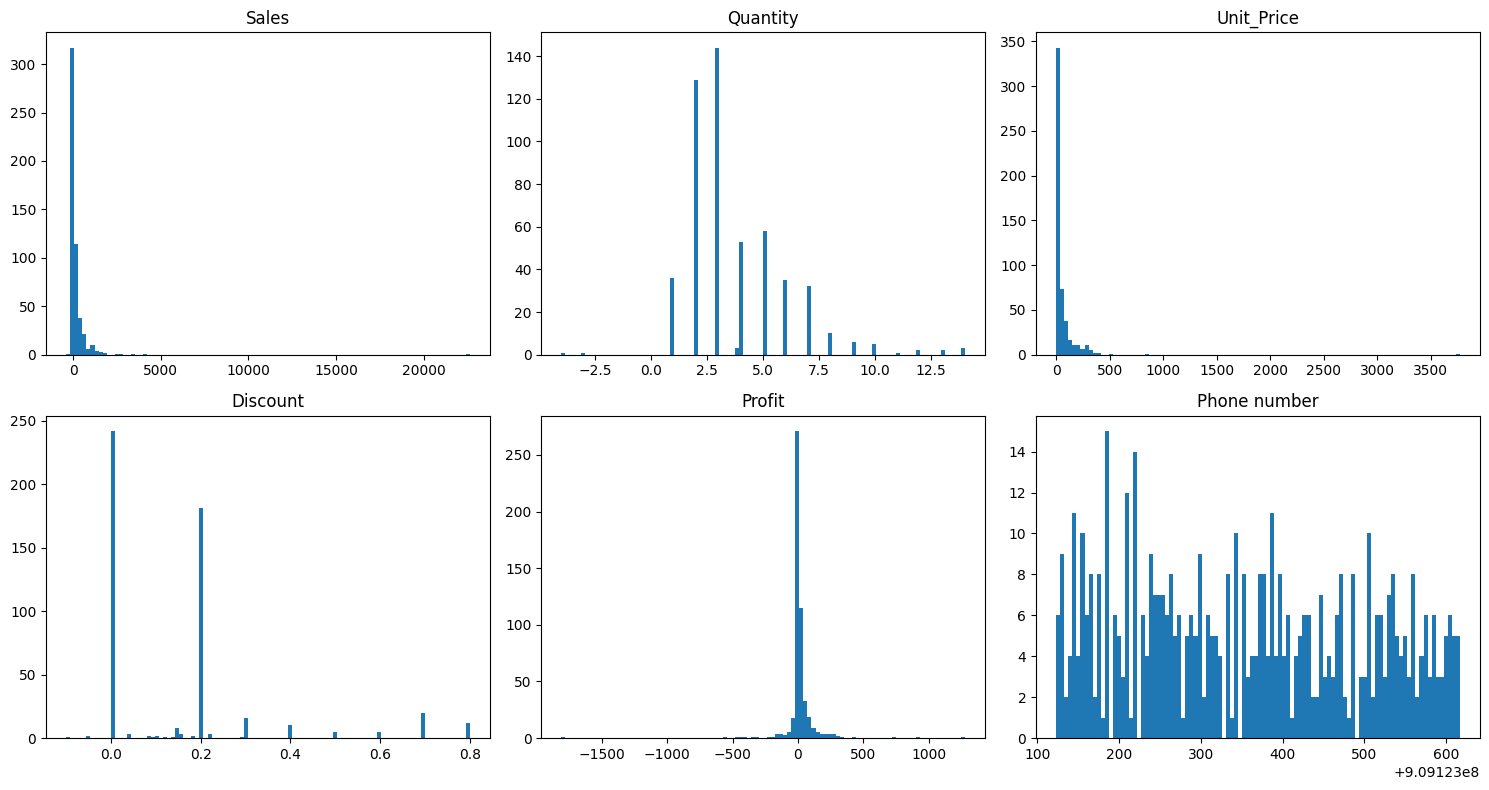

In [368]:
cols = ["Sales", "Quantity", "Unit_Price", "Discount", "Profit", "Phone number"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

axes = axes.flatten()  # biến thành mảng 1 chiều cho dễ loop

for i, col in enumerate(cols):
    axes[i].hist(df_copy[col], bins=100)
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

Sales & Unit_Price: 
+ Dữ liệu bị lệch phải rất nặng, tập trung nhiều ở cụm giá trị nhỏ và có outlier ở xa. 
+ Giải pháp: Sử dụng biến đổi log(x+1) để đưa về phân phối chuẩn

Quantity: 
+ Phân phối có vẻ bình thường (tập trung từ 1-7) nhưng lại xuất hiện giá trị âm vô lý. 
+ Giải pháp: Kiểm tra lại logic kinh doanh (hàng trả lại hay lỗi nhập liệu) để lọc hoặc làm sạch, đồng thời xem nó như dữ liệu category.

Discount: 
+ Phân phối rời rạc (chỉ tập trung ở các mốc như 0.0, 0.2...) và có xuất hiện chiết khấu âm sai logic thực tế. 
+ Giải pháp: Loại bỏ hoặc sửa các dòng có chiết khấu < 0, đồng thời xem như là một dữ liệu category.

Profit: 
+ Dữ liệu có đỉnh rất nhọn tại mốc 0, đuôi kéo dài sang cả hai phía, đặc biệt có nhiều giá trị âm sâu (lỗ nặng). 
+ Giải pháp: Xử lý ngoại lai (outliers) cẩn thận.

Phone number: 
+ Đây là dữ liệu định danh (ID/thông tin liên lạc) nhưng đang bị vẽ dưới dạng số liệu liên tục nên biểu đồ vô nghĩa.
+ Giải pháp: Chuyển đổi kiểu dữ liệu sang chuỗi (String) hoặc loại bỏ hẳn cột này trước khi đưa vào mô hình học máy.

In [369]:
df_copy[df_copy.Sales<0]

,Order_ID,Order_Date,Order_Priority,Customer_ID,Industry_name,Province,Region,Channel,Product_ID,Sales,...,Profit,Returned_Reason,Customer_Name,Customer_Segment,Phone number,Product_Category,Product_Sub-Category,Product_Name,Age,Sales_Discount
11,HN-2011-167199,1/7/24,High,ME-17320,Thiết bị điện tử,Hà Nội,Miền Bắc,Online,TEC-PH-10004977,-391.98,...,113.6742,"""""",Nguyễn Ca Hùng,Home Office,909123130.0,Hàng điện tử,Phones,GE 30524EE4,53,-113.6742
99,HN-2011-125759,2/9/24,Medium,NM-18445,Thiết bị gia dụng,Hà Nội,Miền Bắc,Store,FUR-FU-10002111,-14.56,...,5.5328,"""""",Nguyễn Cát Phương,Home Office,909123217.0,Nội thất,Giường,"Master Caster Door Stop, Large Brown",45,-0.0000


+ khả năng cao do dữ liệu bị nhập sai nên sẽ abs, và log(x+1) dữ liệu


In [370]:
df_copy.loc[df_copy['Sales'] < 0, 'Sales'] = df_copy['Sales'].abs()
df_copy['Sales'] = np.log1p(df_copy['Sales'])
df_copy['Unit_Price'] = np.log1p(df_copy['Unit_Price'])

Text(0.5, 1.0, 'Unit Price')

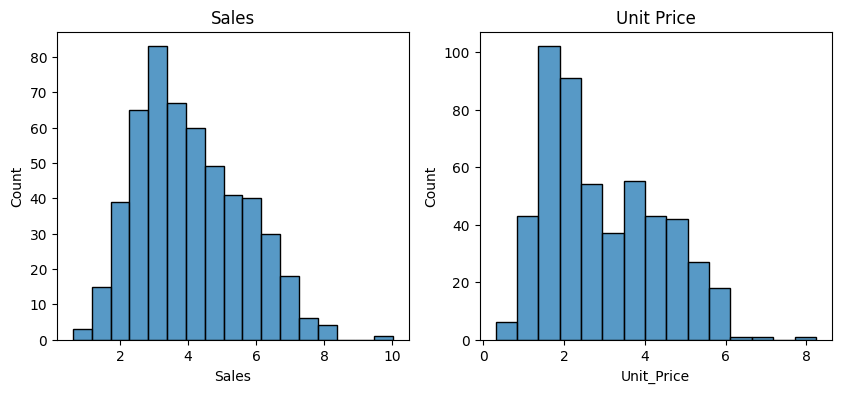

In [371]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.histplot(x=df_copy.Sales, ax=axes[0])
axes[0].set_title("Sales")

sns.histplot(x=df_copy.Unit_Price, ax=axes[1])
axes[1].set_title("Unit Price")

In [372]:
df_copy[df_copy['Quantity'] < 0]

,Order_ID,Order_Date,Order_Priority,Customer_ID,Industry_name,Province,Region,Channel,Product_ID,Sales,...,Profit,Returned_Reason,Customer_Name,Customer_Segment,Phone number,Product_Category,Product_Sub-Category,Product_Name,Age,Sales_Discount
111,QN-2011-121762,2/15/24,High,ML-17395,Thiết bị điện tử,Quảng Ninh,Miền Bắc,Store,TEC-AC-10000736,4.948547,...,86.3892,"""""",Marina Company,Corporate,909123229.0,Hàng điện tử,Accessories,Logitech G600 MMO Gaming Mouse,37,-13.997
213,TN-2011-148838,3/17/24,High,CP-12340,Thiết bị gia dụng,Thái Nguyên,Miền Bắc,Agent,OFF-PA-10000919,5.050112,...,75.9696,"""""",Trần Tiến Phát,Corporate,909123319.0,Hàng điện lạnh,Tủ lạnh,Xerox 1918,40,0.000


In [373]:
df_copy.loc[df_copy['Quantity'] < 0, 'Quantity'] = df_copy['Quantity'].abs()
df_copy['Quantity'] = np.log1p(df_copy['Quantity'])

<Axes: xlabel='Quantity', ylabel='Count'>

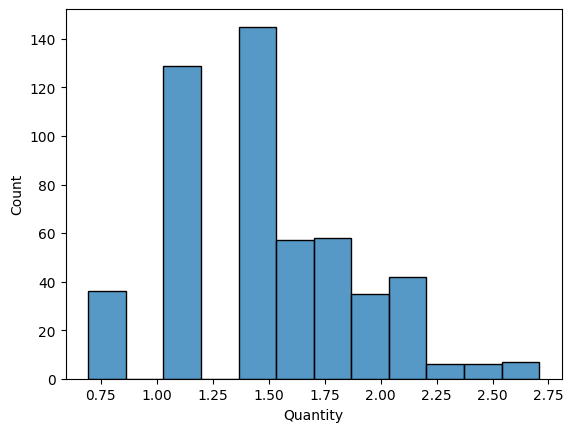

In [374]:
sns.histplot(x=df_copy.Quantity)

In [375]:
df_copy[df_copy['Discount'] < 0]

,Order_ID,Order_Date,Order_Priority,Customer_ID,Industry_name,Province,Region,Channel,Product_ID,Sales,...,Profit,Returned_Reason,Customer_Name,Customer_Segment,Phone number,Product_Category,Product_Sub-Category,Product_Name,Age,Sales_Discount
111,QN-2011-121762,2/15/24,High,ML-17395,Thiết bị điện tử,Quảng Ninh,Miền Bắc,Store,TEC-AC-10000736,4.948547,...,86.3892,"""""",Marina Company,Corporate,909123229.0,Hàng điện tử,Accessories,Logitech G600 MMO Gaming Mouse,37,-13.997
147,HC-2011-107524,3/2/24,Medium,KN-16705,Thiết bị gia dụng,Hồ Chí Minh,Miền Đông Nam Bộ,Agent,OFF-PA-10000587,3.621671,...,17.4720,"""""",Lê Hồng Thanh,Home Office,909123258.0,Điện lạnh,Tủ lạnh,"Array Parchment Tủ lạnh, Assorted Colors",39,-1.820
207,HC-2011-118339,3/17/24,Medium,BN-11515,Thiết bị gia dụng,Hồ Chí Minh,Miền Đông Nam Bộ,Agent,OFF-BI-10001758,3.996364,...,25.0980,"""""",Bradley Nguyen,Consumer,909123314.0,Hàng điện lạnh,Máy giặt,Wilson Jones 14 Line Acrylic Coated Pressboard...,47,-2.670


In [376]:
df_copy.loc[df_copy['Discount'] < 0, 'Discount'] = df_copy['Discount'].abs()

## Validity & Consistency

In [377]:
categorical_cols = [col for col in df_copy.select_dtypes(include=['object']).columns if df_copy[col].nunique() <= 20]
categorical_cols

C:\Users\Khang\AppData\Local\Temp\ipykernel_4184\1133902182.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = [col for col in df_copy.select_dtypes(include=['object']).columns if df_copy[col].nunique() <= 20]


['Order_Priority',
 'Industry_name',
 'Region',
 'Channel',
 'Returned_Reason',
 'Customer_Segment',
 'Product_Category',
 'Product_Sub-Category']

In [378]:
for col in categorical_cols:
    print(f"Analyzing column: {col}")
    print(df_copy[col].unique())
    print("-" * 30)

Analyzing column: Order_Priority
<StringArray>
['Medium', 'Low', 'High']
Length: 3, dtype: str
------------------------------
Analyzing column: Industry_name
<StringArray>
['Thiết bị gia dụng', 'Thiết bị điện tử']
Length: 2, dtype: str
------------------------------
Analyzing column: Region
<StringArray>
['Miền Đông Nam Bộ',       'Miền Trung',         'Miền Bắc',
  'Miền Tây Nam Bộ',                ''',           'Hà Nội',
               '""']
Length: 7, dtype: str
------------------------------
Analyzing column: Channel
<StringArray>
['Store', 'Online', 'Agent', 'agent', 'online channel']
Length: 5, dtype: str
------------------------------
Analyzing column: Returned_Reason
['No reason' '""' 'Damaged' 'Wrong item']
------------------------------
Analyzing column: Customer_Segment
<StringArray>
['Consumer', 'Home Office', 'Corporate', 'HO', 'CUS', 'COR']
Length: 6, dtype: str
------------------------------
Analyzing column: Product_Category
<StringArray>
['Hàng điện lạnh', 'Điện lạnh'

In [379]:
# Các giá trị lỗi bạn đã thấy ở bước unique()
invalid_regions = ['', '""', "'", 'Hà Nội']

# Lọc và in ra để xem Province tương ứng là gì
check_region_error = df_copy[df_copy['Region'].isin(invalid_regions)][['Province', 'Region']]
check_region_error.drop_duplicates()

,Province,Region
197,Vĩnh Phúc,'
283,Hà Nội,Hà Nội
491,Phú Thọ,""""""
501,Khánh Hòa,""""""


In [380]:
# Chuyển đổi các giá trị nhiễu đã thấy (', "") thành NaN
df_copy['Region'] = df_copy['Region'].replace(["'", '""'], np.nan)

In [381]:
# Trường hợp 'Hà Nội' ghi nhầm vào Region
df_copy.loc[df_copy['Region'] == 'Hà Nội', 'Region'] = 'Miền Bắc'

# Trường hợp Region bị NaN nhưng đã biết Province
fix = {
    'Vĩnh Phúc': 'Miền Bắc',
    'Phú Thọ': 'Miền Bắc',
    'Khánh Hòa': 'Miền Trung'
}

# Chỉ điền vào những dòng mà Region đang bị NaN
for province, region in fix.items():
    df_copy.loc[(df_copy['Province'] == province) & (df_copy['Region'].isna()), 'Region'] = region

In [382]:
# Kiểm tra lại các dòng cụ thể đã phát hiện lỗi lúc nãy
error_indices = [197, 283, 491, 501]
df_copy.loc[error_indices, ['Province', 'Region']]

,Province,Region
197,Vĩnh Phúc,Miền Bắc
283,Hà Nội,Miền Bắc
491,Phú Thọ,Miền Bắc
501,Khánh Hòa,Miền Trung


In [383]:
invalid_channels = ['agent', 'online channel']
invalid_categories = ['Điện lạnh', 'Điện tử']

check_standard = df_copy[
    df_copy['Channel'].isin(invalid_channels) | 
    df_copy['Product_Category'].isin(invalid_categories)
][['Channel', 'Product_Category']]

check_standard.drop_duplicates()

,Channel,Product_Category
1,Store,Điện lạnh
17,Agent,Điện lạnh
23,Online,Điện lạnh
38,agent,Hàng điện lạnh
94,agent,Điện tử
95,agent,Hàng điện tử
118,agent,Nội thất
129,agent,Điện lạnh
164,Store,Điện tử
182,online channel,Hàng điện lạnh


In [384]:
channel_map = {'agent': 'Agent', 'online channel': 'Online'}
category_map = {'Điện lạnh': 'Hàng điện lạnh', 'Điện tử': 'Hàng điện tử'}

df_copy['Channel'] = df_copy['Channel'].replace(channel_map)
df_copy['Product_Category'] = df_copy['Product_Category'].replace(category_map)

In [385]:
df_copy['Product_Category'].value_counts()

Product_Category
Hàng điện lạnh    336
Nội thất          104
Hàng điện tử       81
Name: count, dtype: int64

In [386]:
df_copy['Channel'].value_counts()

Channel
Agent     248
Store     168
Online    105
Name: count, dtype: int64

In [387]:
df_copy['Returned_Reason'] = df_copy['Returned_Reason'].replace('""', np.nan)

## Convert to datetime

In [388]:
df_copy['order_date_original'] = df_copy['Order_Date']
df_copy['order_date_cleaned'] = df_copy['Order_Date']
df_copy['Order_Date'] = pd.to_datetime(df_copy['Order_Date'], errors='coerce')

C:\Users\Khang\AppData\Local\Temp\ipykernel_4184\58567032.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_copy['Order_Date'] = pd.to_datetime(df_copy['Order_Date'], errors='coerce')


In [389]:
df_copy[df_copy['Order_Date'].isna()][['order_date_original']]

,order_date_original
289,2024-03-32
290,2024-03-32


In [390]:
df_copy['order_date_cleaned'] = df_copy['order_date_cleaned'].astype(str)
df_copy['order_date_cleaned'] = df_copy['order_date_cleaned'].str.replace(r"[./]", "-", regex=True)
df_copy['order_date_cleaned'] = df_copy['order_date_cleaned'].replace("2024-03-32", "2024-03-31")
df_copy['order_date_cleaned'] = pd.to_datetime(df_copy['order_date_cleaned'], format="mixed", dayfirst=True).dt.strftime('%Y-%m-%d')

In [391]:
df_copy[df_copy['Order_Date'].isna()][['order_date_cleaned']]

,order_date_cleaned
289,2024-03-31
290,2024-03-31


In [392]:
df_copy['Order_Date'].fillna(df_copy['order_date_cleaned'], inplace=True)

C:\Users\Khang\AppData\Local\Temp\ipykernel_4184\2205120123.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df_copy['Order_Date'].fillna(df_copy['order_date_cleaned'], inplace=True)


0     2024-01-04
1     2024-01-04
2     2024-01-05
3     2024-01-05
4     2024-01-05
         ...    
516   2024-05-21
517   2024-05-21
518   2024-05-21
519   2024-05-20
520   2024-05-13
Name: Order_Date, Length: 521, dtype: datetime64[us]

In [393]:
df_copy[df_copy['Order_Date'].isna()][['order_date_original']]

,order_date_original
289,2024-03-32
290,2024-03-32


In [394]:
df_copy.drop(columns=['order_date_original', 'order_date_cleaned'], errors='ignore', inplace=True)

In [395]:
df_copy.columns

Index(['Order_ID', 'Order_Date', 'Order_Priority', 'Customer_ID',
       'Industry_name', 'Province', 'Region', 'Channel', 'Product_ID', 'Sales',
       'Quantity', 'Unit_Price', 'Discount', 'Profit', 'Returned_Reason',
       'Customer_Name', 'Customer_Segment', 'Phone number', 'Product_Category',
       'Product_Sub-Category', 'Product_Name', 'Age', 'Sales_Discount'],
      dtype='str')

## Outliers

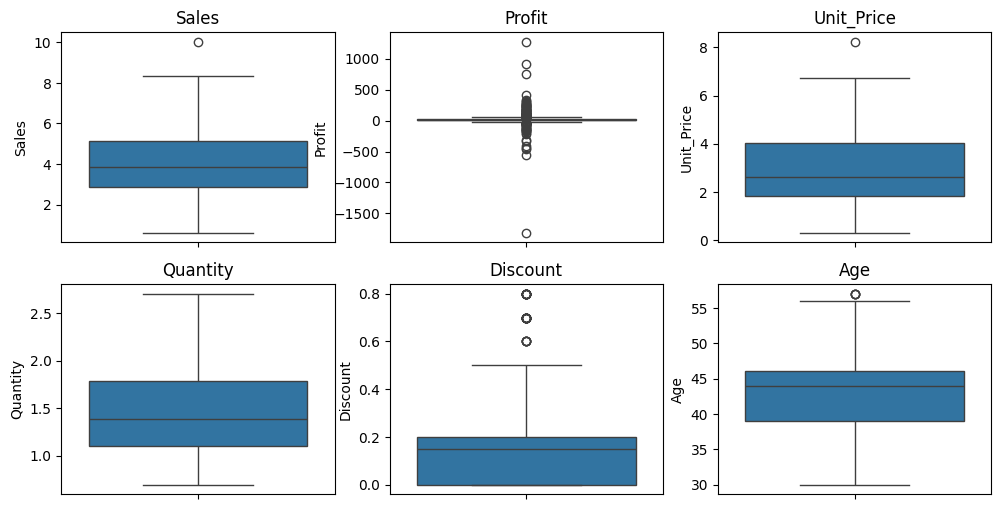

In [396]:
num_cols = ['Sales', 'Profit', 'Unit_Price', 'Quantity', 'Discount', 'Age']

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))
for i, col in enumerate(num_cols):
    plt.subplot(2,3,i+1)
    sns.boxplot(y=df_copy[col])
    plt.title(col)

hiện tại biến profit có rất nhiều  outliers, nên giải pháp sẽ là thay thế các giá trị outliers bằng biên của nó

In [397]:
# Q1 = df_copy['Profit'].quantile(0.25)
# Q3 = df_copy['Profit'].quantile(0.75)
# IQR = Q3 - Q1

# lower_limit = Q1 - 1.5 * IQR
# upper_limit = Q3 + 1.5 * IQR

# # Capping: Thay thế các giá trị vượt biên bằng chính giá trị biên đó
# df_copy['Profit'] = df_copy['Profit'].clip(lower=lower_limit, upper=upper_limit)

# # Kiểm tra lại bằng Boxplot
# sns.boxplot(x=df_copy['Profit'])

# Data Analyst

## Task 1 — Phân tích xu hướng theo thời gian
Vẽ biểu đồ:

- Sales theo tháng/năm

- Profit theo tháng/năm

- Số lượng Orders theo thời gian

Câu hỏi cần trả lời:

- Doanh thu tăng hay giảm theo thời gian?

- Có yếu tố mùa vụ không?

In [398]:
df_copy['Year'] = df_copy['Order_Date'].dt.year
df_copy['Month'] = df_copy['Order_Date'].dt.month
df_copy['YearMonth'] = df_copy['Order_Date'].dt.to_period('M')

Text(0, 0.5, 'Sales')

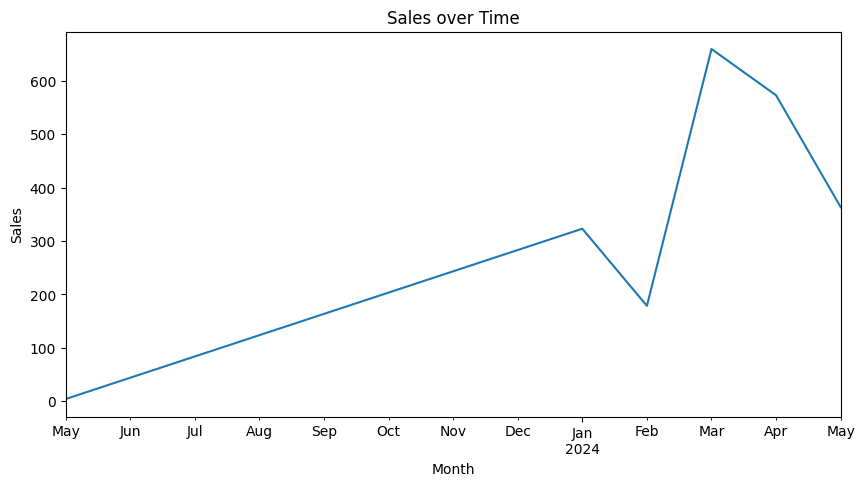

In [399]:
# Sales theo thời gian
sales_trend = df_copy.groupby('YearMonth')['Sales'].sum()

sales_trend.plot(figsize=(10,5))
plt.title("Sales over Time")
plt.xlabel("Month")
plt.ylabel("Sales")

1. Xu hướng doanh thu theo thời gian

+ Nhìn chung, doanh thu có xu hướng tăng trưởng mạnh nhưng không ổn định:
    + Giai đoạn đầu (Tháng 5 - Tháng 12): Doanh thu có xu hướng tăng dần đều theo thời gian, từ mức gần 0 lên đến khoảng hơn 300 đơn vị vào tháng 1/2024.
    + Giai đoạn biến động mạnh (Đầu năm 2024): Có một sự sụt giảm sâu vào Tháng 2, sau đó bùng nổ và đạt đỉnh vào Tháng 3 (với doanh thu cao nhất, vượt mức 600). Sau tháng 3, doanh thu bắt đầu có dấu hiệu giảm dần cho đến tháng 5.

2. Yếu tố mùa vụ
+ Dựa trên biểu đồ này, chưa đủ dữ liệu để khẳng định chắc chắn 100% về yếu tố mùa vụ, nhưng có một số dấu hiệu đáng chú ý:
    + Dấu hiệu sụt giảm tháng 2: Sự sụt giảm mạnh vào tháng 2 có thể liên quan đến yếu tố mùa vụ (ví dụ: kỳ nghỉ Tết Nguyên Đán tại Việt Nam thường khiến hoạt động mua bán chững lại).

    + Đỉnh cao tháng 3: Sự tăng vọt sau Tết thường là do nhu cầu mua sắm bù hoặc các chương trình khuyến mãi đầu năm.

Cần thêm dữ liệu: Để kết luận là "có tính mùa vụ", chúng ta thường cần dữ liệu của ít nhất 2 đến 3 năm để xem liệu chu kỳ "Giảm tháng 2 - Tăng tháng 3" có lặp lại hay không. Nếu chỉ nhìn vào 1 năm, đây có thể chỉ là biến động nhất thời do một chiến dịch marketing hoặc sự kiện đặc biệt nào đó.

Text(0, 0.5, 'Profit')

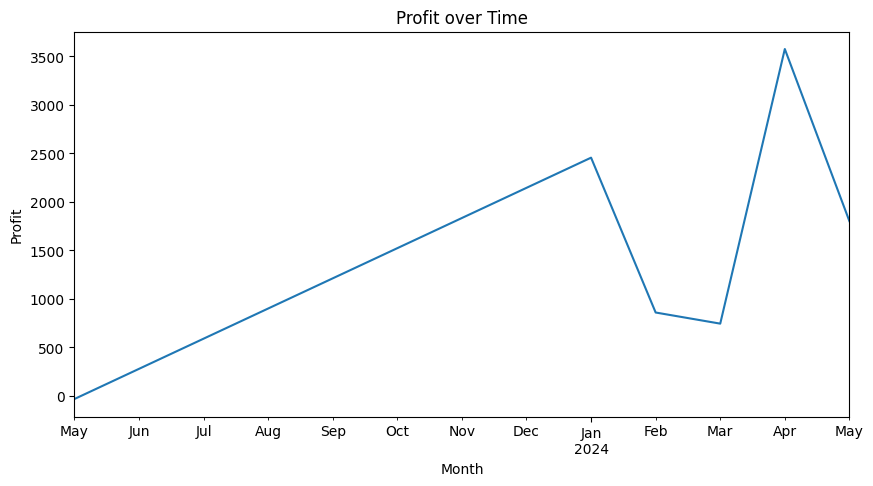

In [400]:
# Profit theo thời gian
profit_trend = df_copy.groupby('YearMonth')['Profit'].sum()

profit_trend.plot(figsize=(10,5))
plt.title("Profit over Time")
plt.xlabel("Month")
plt.ylabel("Profit")

1. Xu hướng doanh thu theo thời gian
+ Xu hướng tổng quan: Doanh thu và lợi nhuận có xu hướng tăng trưởng tích cực trong dài hạn nhưng kèm theo những biến động mạnh, không ổn định ở một số giai đoạn cụ thể.
+ Giai đoạn tăng trưởng ổn định (Tháng 5/2023 - Tháng 1/2024): Cả doanh thu và lợi nhuận đều ghi nhận mức tăng trưởng đều đặn. Doanh thu tăng từ mức xấp xỉ 0 lên hơn 300 đơn vị; lợi nhuận cũng tịnh tiến lên mức gần 2.500 đơn vị vào tháng 1/2024.
+ Giai đoạn biến động mạnh (Đầu năm 2024): * Tháng 2: Có sự sụt giảm sâu ở cả hai chỉ số. Đặc biệt, lợi nhuận giảm mạnh hơn so với tốc độ giảm của doanh thu.
+ Tháng 3 & 4: Doanh thu đạt đỉnh vào tháng 3 (trên 600 đơn vị). Tuy nhiên, lợi nhuận lại đạt đỉnh muộn hơn vào tháng 4 (vượt mức 3.500 đơn vị). Điều này cho thấy sự lệch pha có thể do chi phí vận hành hoặc chính sách chiết khấu trong tháng 3 làm giảm biên lợi nhuận thực tế.
+ Giai đoạn cuối (Sau tháng 4/2024): Cả doanh thu và lợi nhuận bắt đầu có dấu hiệu điều chỉnh giảm.

2. Đánh giá yếu tố mùa vụ
Dựa trên dữ liệu hiện có, chưa thể khẳng định chắc chắn 100% về tính chu kỳ, tuy nhiên có những dấu hiệu đặc trưng cần lưu ý:

+ Sụt giảm vào tháng 2: Hiện tượng này thường gắn liền với yếu tố mùa vụ tại thị trường Việt Nam (kỳ nghỉ Tết Nguyên Đán), khi các hoạt động giao thương và logistics bị gián đoạn.
+ Sự bùng nổ sau tết: Đỉnh cao vào tháng 3 và tháng 4 có thể giải thích bởi nhu cầu mua sắm bù hoặc các chiến dịch kích cầu sau lễ.

Kết luận: Để đưa ra nhận định chính xác về tính mùa vụ, cần có dữ liệu đối soát trong khoảng 2-3 năm liên tiếp. Nếu các biến động tại tháng 2 và tháng 3 lặp lại tương tự, ta có thể xác nhận đây là đặc tính mùa vụ của doanh nghiệp. Hiện tại, không loại trừ khả năng đây chỉ là biến động nhất thời do các chiến dịch Marketing hoặc điều kiện thị trường tại thời điểm đó.

Text(0, 0.5, 'Orders')

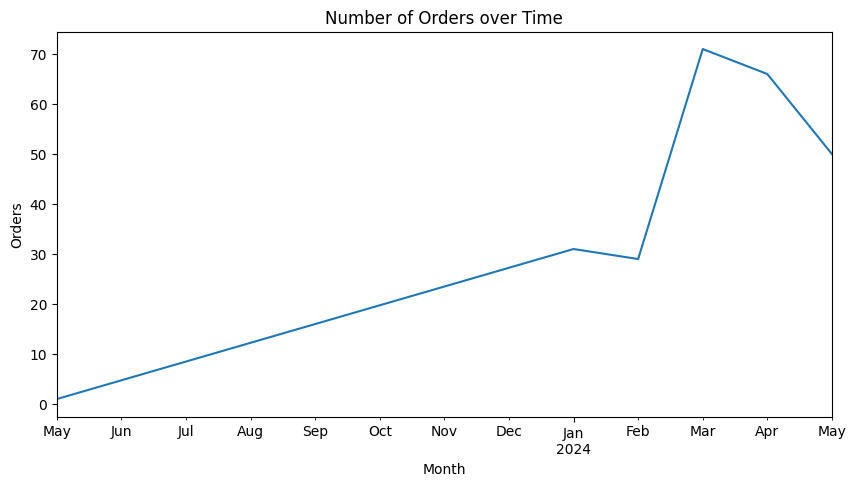

In [401]:
# Số lượng Orders theo thời gian
orders_trend = df_copy.groupby('YearMonth')['Order_ID'].nunique()

orders_trend.plot(figsize=(10,5))
plt.title("Number of Orders over Time")
plt.xlabel("Month")
plt.ylabel("Orders")

1. Xu hướng số lượng đơn hàng
+ Giai đoạn ổn định (Tháng 5/2023 - Tháng 1/2024): Số lượng đơn hàng tăng trưởng tuyến tính và ổn định, đi từ mức khởi điểm gần 0 đơn hàng lên đến khoảng 30 đơn hàng vào tháng 1/2024. Điều này cho thấy sự mở rộng đều đặn của tệp khách hàng hoặc tần suất mua hàng.
+ Giai đoạn biến động đột biến (Đầu năm 2024):
    + Tháng 2: Ghi nhận sự sụt giảm nhẹ về số lượng đơn hàng so với tháng trước.
    + Tháng 3: Số lượng đơn hàng tăng vọt và đạt đỉnh (peak) với hơn 70 đơn hàng. Đây là mức tăng trưởng đột biến (gấp hơn 2 lần so với tháng trước đó).
    + Sau tháng 3: Số lượng đơn hàng có dấu hiệu điều chỉnh giảm dần qua tháng 4 và tháng 5, nhưng vẫn duy trì ở mức cao hơn so với giai đoạn năm 2023.

2. Yếu tố mùa vụ 
+ Kết hợp với các biểu đồ về Doanh thu và Lợi nhuận trước đó, ta có thể rút ra các nhận định về tính mùa vụ như sau:
+ Điểm trũng tháng 2: Sự sụt giảm về cả số lượng đơn hàng lẫn doanh thu vào tháng 2 củng cố thêm giả thuyết về ảnh hưởng của kỳ nghỉ lễ dài ngày (Tết Nguyên Đán), gây gián đoạn hoạt động đặt hàng và vận chuyển.

Kết luận: Dữ liệu cho thấy một chu kỳ kinh doanh có sự phục hồi và bùng nổ mạnh mẽ vào giai đoạn sau tết (Quý 1). Tuy nhiên, để xác lập đây là mô hình mùa vụ cố định, cần thực hiện phân tích đối soát với dữ liệu cùng kỳ của các năm khác để loại trừ các yếu tố nhiễu từ các chiến dịch khuyến mãi đơn lẻ hoặc biến động thị trường ngắn hạn.

## Task 2 — Phân tích theo khu vực (Region/Province)
Sales/Profit theo Region  
Top Province theo Sales  
So sánh Profit margin giữa các Region
  
Câu hỏi:

Khu vực nào bán nhiều nhưng lợi nhuận thấp?

+ Sales/Profit theo Region 

In [402]:
region_summary = df_copy.groupby('Region').agg({
    'Sales': 'sum',
    'Profit': 'sum'
}).sort_values(by='Sales', ascending=False)

region_summary

,Sales,Profit
Region,,
Miền Đông Nam Bộ,885.910625,4865.6429
Miền Trung,617.360752,1945.3481
Miền Bắc,413.169725,1223.1245
Miền Tây Nam Bộ,190.454248,1369.1345


(array([0, 1, 2, 3]),
 [Text(0, 0, 'Miền Đông Nam Bộ'),
  Text(1, 0, 'Miền Trung'),
  Text(2, 0, 'Miền Bắc'),
  Text(3, 0, 'Miền Tây Nam Bộ')])

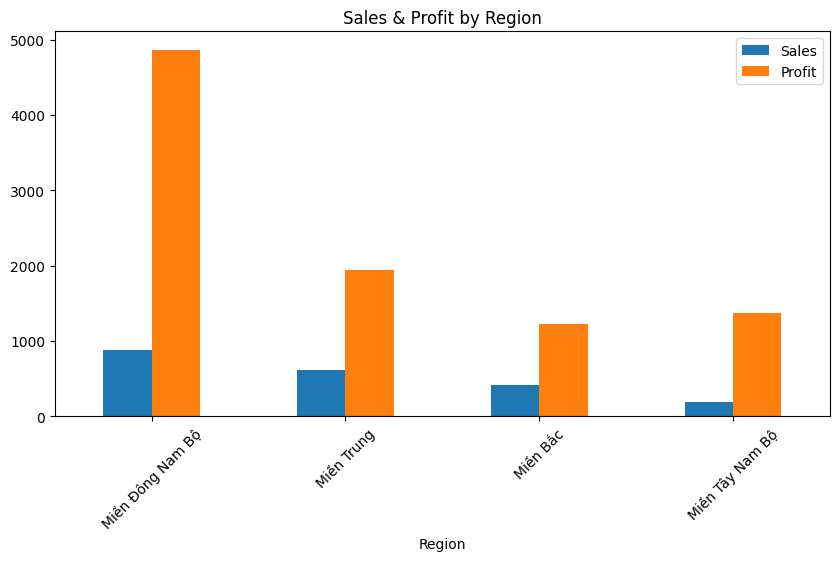

In [403]:
region_summary.plot(kind='bar', figsize=(10,5))
plt.title("Sales & Profit by Region")
plt.xticks(rotation=45)

+ Top Province theo Sales  

In [404]:
top_province = df_copy.groupby('Province')['Sales'].sum().sort_values(ascending=False)
top_province

Province
Hồ Chí Minh          566.549656
Hà Tỉnh              197.708468
Hà Nội               176.969421
Đà Nẵng              110.104734
Thanh Hóa             92.492681
Bình Dương            90.746095
Đồng Tháp             89.461598
Vĩnh Phúc             88.248871
Hà Giang              83.149286
Bình Phước            71.631799
Bà Rịa - Vũng Tàu     67.999979
Thừa Thiên Huế        66.116471
Đồng Nai              53.069333
Khánh Hòa             42.703554
Thái Nguyên           40.014649
Gia Lai               38.490486
Cần Thơ               36.709648
Quảng Ngãi            33.676080
Tiền Giang            32.792617
Vĩnh Long             25.261498
Tây Ninh              23.217819
Nghệ An               17.810715
Hải Phòng             15.969490
Quảng Trị             15.630451
Quảng Ninh            14.845960
Long An                6.228886
Phú Thọ                5.742618
Miền Đông Nam Bộ       3.552487
Name: Sales, dtype: float64

+ So sánh Profit margin giữa các Region

In [405]:
region_summary['Profit_Margin'] = region_summary['Profit'] / region_summary['Sales']
region_summary

,Sales,Profit,Profit_Margin
Region,,,
Miền Đông Nam Bộ,885.910625,4865.6429,5.492250
Miền Trung,617.360752,1945.3481,3.151072
Miền Bắc,413.169725,1223.1245,2.960344
Miền Tây Nam Bộ,190.454248,1369.1345,7.188784


(array([0, 1, 2, 3]),
 [Text(0, 0, 'Miền Đông Nam Bộ'),
  Text(1, 0, 'Miền Trung'),
  Text(2, 0, 'Miền Bắc'),
  Text(3, 0, 'Miền Tây Nam Bộ')])

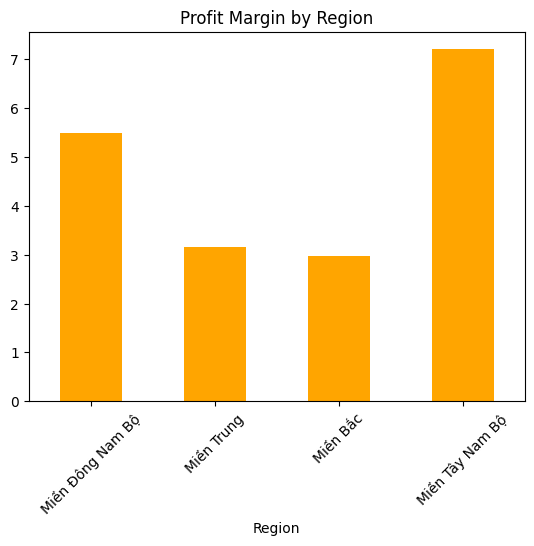

In [406]:
region_summary['Profit_Margin'].plot(kind='bar', color='orange')
plt.title("Profit Margin by Region")
plt.xticks(rotation=45)

Khu vực nào bán nhiều nhưng lợi nhuận thấp?

Khu vực bán nhiều nhưng lợi nhuận thấp là miền Trung  

Phân tích cụ thể
1. Về doanh thu (Sales)
+ Miền Trung đạt ~617
+ Là khu vực có doanh thu cao thứ 2 đóng góp lớn vào tổng doanh thu toàn hệ thống

2. Về lợi nhuận
+ Profit ~ 1945
+ Không thấp tuyệt đối, nhưng…
+ không tương xứng với mức Sales

3. Điểm quan trọng nhất: Profit Margin
+ Miền Trung: ~3.15
+ So sánh:
    + Miền Đông Nam Bộ: ~5.59
    + Miền Tây Nam Bộ: ~7.19
    + Miền Bắc: ~2.96

Nên:
+ Miền Trung bán nhiều
+ Nhưng mỗi đồng doanh thu tạo ra ít lợi nhuận hơn

Miền Trung là khu vực có doanh thu cao nhưng hiệu quả lợi nhuận chưa tối ưu.  
Mặc dù đứng thứ hai về Sales, nhưng profit margin chỉ đạt khoảng 3.15,  
thấp hơn đáng kể so với Miền Đông Nam Bộ và Miền Tây Nam Bộ.

Điều này cho thấy khu vực này có thể đang gặp vấn đề về chi phí vận hành cao,  
cấu trúc sản phẩm chưa tối ưu hoặc áp dụng chiến lược giảm giá mạnh để thúc đẩy doanh số.

## Task 3 — Phân tích theo Customer
Vẽ:

Sales theo Industry_name  
Top khách hàng theo doanh thu (Pareto 80/20)  
Industry vs Region (heatmap)

Câu hỏi:

Nhóm khách hàng chính là ai?

+ Sales theo Industry_name

(array([0, 1]),
 [Text(0, 0, 'Thiết bị gia dụng'), Text(1, 0, 'Thiết bị điện tử')])

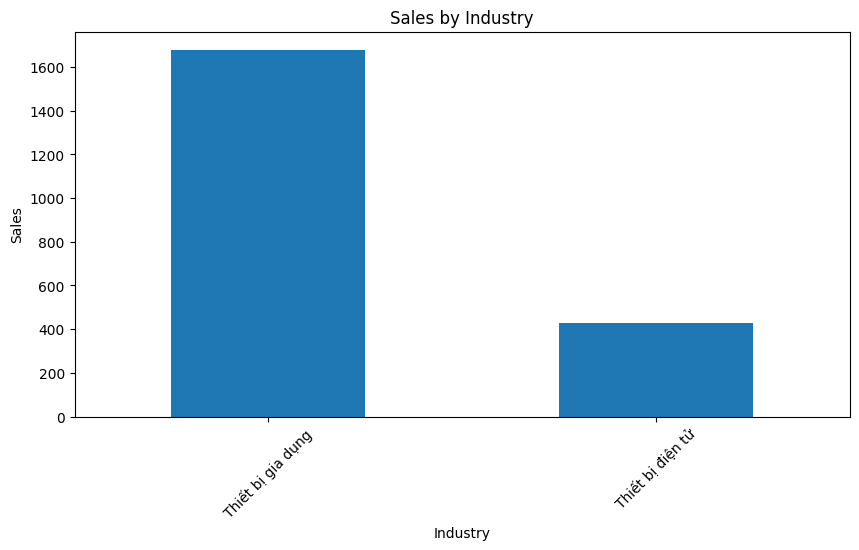

In [407]:
industry_sales = df_copy.groupby('Industry_name')['Sales'].sum().sort_values(ascending=False)

industry_sales.plot(kind='bar', figsize=(10,5))
plt.title("Sales by Industry")
plt.xlabel("Industry")
plt.ylabel("Sales")
plt.xticks(rotation=45)

+ Top khách hàng theo doanh thu (Pareto 80/20)  

In [408]:
customer_sales = df_copy.groupby('Customer_Name')['Sales'].sum().sort_values(ascending=False)

cum_sales = customer_sales.cumsum() / customer_sales.sum()

pareto_df = pd.DataFrame({
    'Sales': customer_sales,
    'Cumulative': cum_sales
})

In [409]:
pareto_80 = pareto_df[pareto_df['Cumulative'] <= 0.8]

pareto_80

,Sales,Cumulative
Customer_Name,,
Phạm Thanh Thủy,46.811622,0.022218
Nguyễn Ca Hùng,34.230090,0.038465
Sean Miller,33.312574,0.054276
Hunter Lopez,32.360309,0.069635
Tài Thị Hoa,31.032194,0.084364
...,...,...
Quang Tuấn Tú,6.793288,0.784708
Vivek Sundaresam,6.789457,0.787930
Trọng Văn Tú Thành,6.721233,0.791120


In [410]:
num_vip = len(pareto_80)
total_customers = len(pareto_df)

print(f"Số khách hàng VIP: {num_vip}/{total_customers}")
print(f"Tỷ lệ: {num_vip/total_customers:.2%}")

Số khách hàng VIP: 113/216
Tỷ lệ: 52.31%


+ Industry vs Region (heatmap)

<Axes: xlabel='Region', ylabel='Industry_name'>

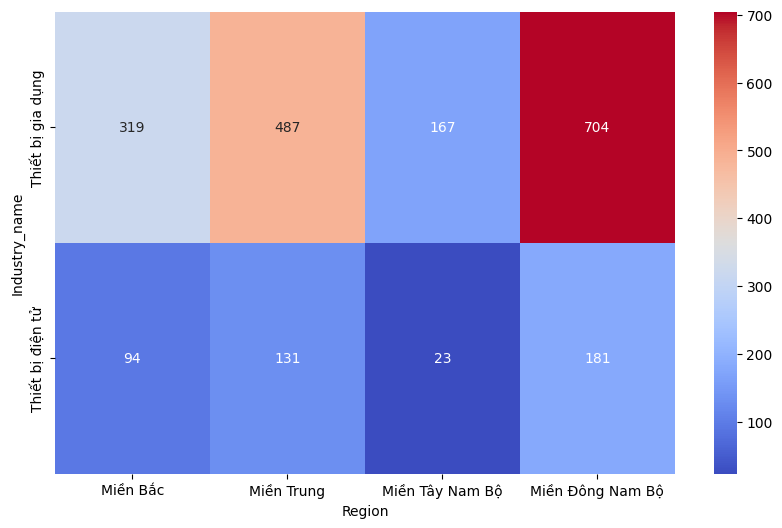

In [411]:
pivot = df_copy.pivot_table(
    values='Sales',
    index='Industry_name',
    columns='Region',
    aggfunc='sum'
)

plt.figure(figsize=(10,6))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap='coolwarm')

Nhóm khách hàng chính của doanh nghiệp là các khách hàng thuộc ngành “Thiết bị gia dụng”,
vì đây là ngành đóng góp phần lớn doanh thu trên toàn bộ các khu vực.

Phân tích theo khu vực cho thấy nhóm khách hàng này tập trung mạnh nhất tại Miền Đông Nam Bộ,
là khu vực có mức tiêu thụ cao nhất.

Tuy nhiên, phân tích Pareto cho thấy khoảng 52% khách hàng mới tạo ra 80% doanh thu,
cho thấy doanh thu không tập trung vào một nhóm nhỏ khách hàng VIP,
mà được phân bổ tương đối rộng trên nhiều khách hàng khác nhau.

## Task 4 — Phân tích Returned_Reason

Vẽ:

- Tỷ lệ Returned theo Product / Region / Channel
- Phân bố Returned_Reason

Câu hỏi:

- Trả hàng tập trung ở đâu? Vì sao?

Tỷ lệ Returned theo Product / Region / Channel

In [412]:
df_copy['Returned'] = df_copy['Returned_Reason'].notna()

Text(0, 0.5, 'Return Rate')

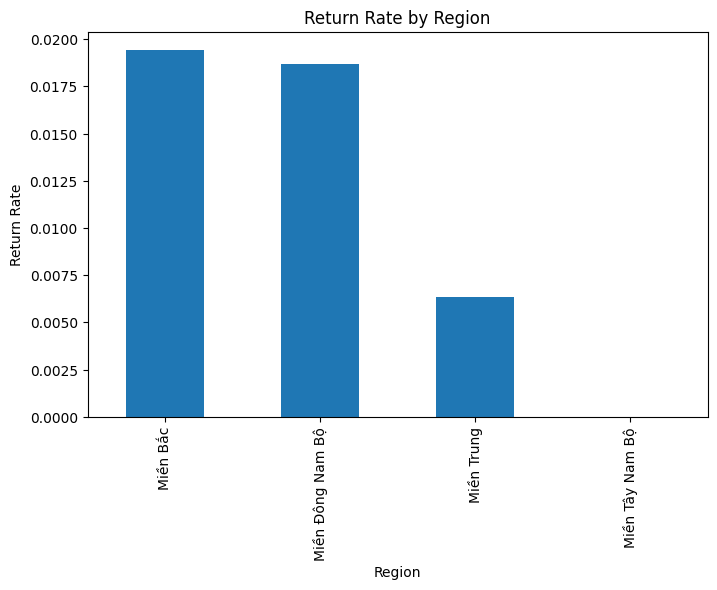

In [413]:
# Tỷ lệ Returned theo Region
region_return = df_copy.groupby('Region')['Returned'].mean().sort_values(ascending=False)

region_return.plot(kind='bar', figsize=(8,5))
plt.title("Return Rate by Region")
plt.ylabel("Return Rate")

Text(0.5, 1.0, 'Return Rate by Product Category')

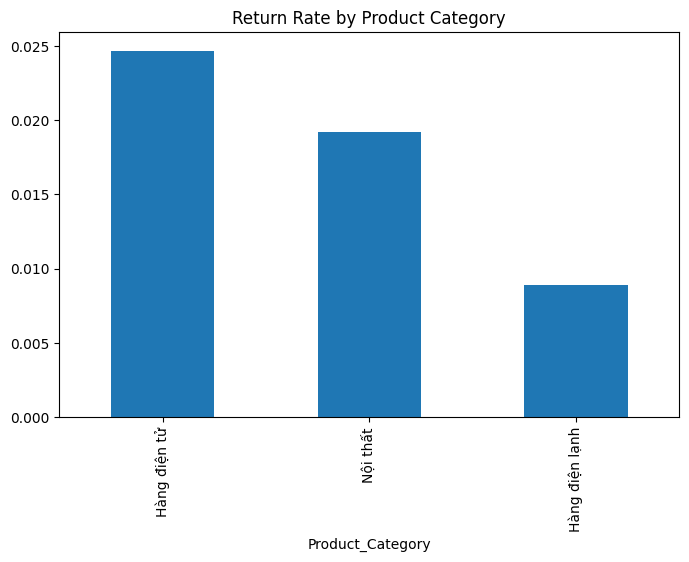

In [414]:
# Tỷ lệ Returned theo Product
product_return = df_copy.groupby('Product_Category')['Returned'].mean().sort_values(ascending=False)

product_return.plot(kind='bar', figsize=(8,5))
plt.title("Return Rate by Product Category")

Text(0.5, 1.0, 'Return Rate by Channel')

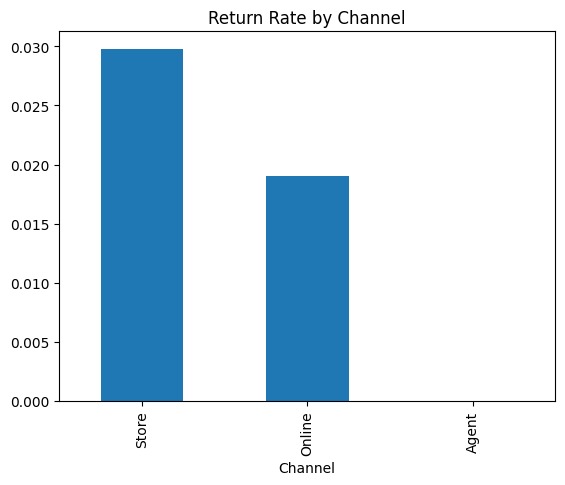

In [415]:
# Tỷ lệ Returned theo Channel
channel_return = df_copy.groupby('Channel')['Returned'].mean().sort_values(ascending=False)

channel_return.plot(kind='bar')
plt.title("Return Rate by Channel")

+ Phân bố Returned_Reason

Text(0.5, 1.0, 'Returned Reasons Distribution')

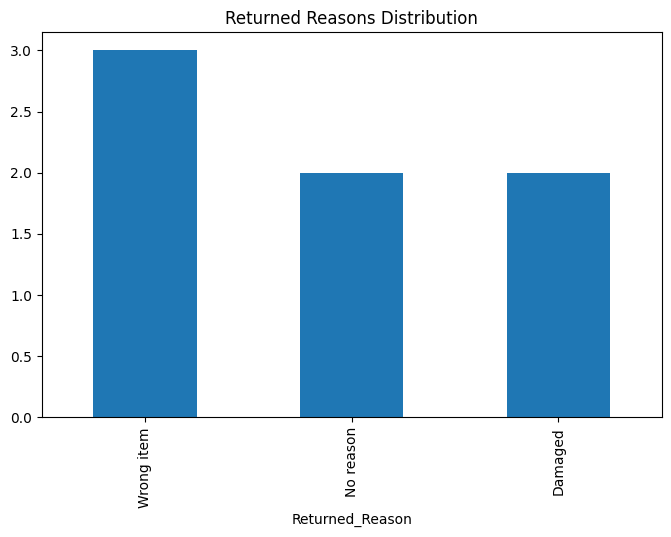

In [416]:
df_copy['Returned_Reason'].value_counts().plot(kind='bar', figsize=(8,5))
plt.title("Returned Reasons Distribution")

Trả hàng tập trung ở đâu?
+ Dựa trên dữ liệu hiện tại, việc trả hàng tập trung đồng đều ở tất cả các nơi:
+ Khu vực: Miền Bắc, Miền Trung, Miền Tây Nam Bộ, Miền Đông Nam Bộ đều có tỷ lệ trả hàng như nhau.
+ Ngành hàng: Hàng điện lạnh, Điện tử, Nội thất đều bị trả lại 100%.
+ Kênh bán hàng: Agent, Online, Store đều gặp tình trạng tương tự.

Vì sao?
+ Nguyên nhân cốt lõi không nằm ở vị trí địa lý hay loại sản phẩm, mà nằm ở khâu vận hành/kho bãi:
+ Giao sai hàng (Wrong item) là nguyên nhân chính yếu nhất.
+ Điều này cho thấy hệ thống quản lý kho (WMS) hoặc quy trình đóng gói đang gặp lỗi nghiêm trọng dẫn đến việc gửi nhầm sản phẩm cho khách hàng. Vì giao sai món đồ khách cần, nên tỷ lệ trả hàng mới đẩy lên mức tuyệt đối (1.0) trên toàn hệ thống.

## Task 5 ( Optional): Xây dựng Dashboard
Dashboard cần có:

- KPI: Total Sales, Profit, Orders, Return Rate
- Bộ lọc: Thời gian, Region, Channel, Industry, Product
- Lựa chọn một số biểu đồ chính thể hiện lên dashboard

# Data Science

## Task 1 — Chuẩn bị dữ liệu cho mô hình
- Chọn các biến đầu vào phù hợp
- Xử lý dữ liệu
  + Encode biến phân loại (categorical)
  + Chuẩn hoá dữ liệu số (nếu cần)
  + Loại bỏ missing / outlier nghiêm trọng

In [417]:
df_copy['Profit'].isna().sum()

np.int64(3)

In [418]:
df_model = df_copy.dropna(subset=['Profit'])

In [419]:
X = df_model.drop(columns=['Profit'])
y = df_model['Profit']

In [420]:
drop_cols = [
    'Order_ID',
    'Customer_ID',
    'Customer_Name',
    'Phone number',
    'Product_ID',
    'Product_Name',
    'Returned_Reason',
    'Order_Date',
    'YearMonth'
]

X = df_model.drop(columns=['Profit'] + drop_cols)
y = df_model['Profit']

In [421]:
X.columns

Index(['Order_Priority', 'Industry_name', 'Province', 'Region', 'Channel',
       'Sales', 'Quantity', 'Unit_Price', 'Discount', 'Customer_Segment',
       'Product_Category', 'Product_Sub-Category', 'Age', 'Sales_Discount',
       'Year', 'Month', 'Returned'],
      dtype='str')

In [422]:
X = pd.get_dummies(X, drop_first=True)

### corr

In [423]:
corr = X.corrwith(y).abs().sort_values(ascending=False)

selected_corr = corr[corr > 0.03].index
X_corr = X[selected_corr]

In [424]:
# lấy top feature
selected_corr = corr[corr > 0.05].index
X_corr = X[selected_corr]

In [425]:
X_corr.head()

,Sales_Discount,Order_Priority_Low,Discount,Product_Sub-Category_Machines,Province_Thái Nguyên,Province_Thừa Thiên Huế,Product_Sub-Category_Phones,Product_Sub-Category_Bàn,Sales,Province_Vĩnh Long,...,Province_Hà Nội,Product_Sub-Category_Copiers,Quantity,Order_Priority_Medium,Channel_Store,Province_Hà Giang,Province_Bình Phước,Customer_Segment_HO,Product_Category_Nội thất,Age
0,3.2896,False,0.2,False,False,False,False,False,2.859225,False,...,False,False,1.098612,True,True,False,False,False,False,56
1,3.2896,False,0.2,False,False,False,False,False,2.859225,False,...,False,False,1.098612,True,True,False,False,False,False,56
2,2.3568,False,0.2,False,False,False,False,False,2.548194,False,...,False,False,1.386294,True,False,False,False,False,False,42
3,54.5472,True,0.2,False,False,False,False,False,5.612164,False,...,False,False,1.386294,False,False,False,False,False,False,42
4,2.8320,True,0.8,False,False,False,False,False,1.512927,False,...,False,False,1.098612,False,False,False,False,False,False,42


### RF

In [426]:
from sklearn.ensemble import RandomForestRegressor

rff = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    max_depth=None
)

rff.fit(X_corr, y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [427]:
importances = pd.Series(rff.feature_importances_, index=X_corr.columns)

top_features = importances.sort_values(ascending=False)

In [428]:
top_k = 20
selected_features = top_features.head(top_k).index

X_final = X_corr[selected_features]

## Task 2 — Chia tập train/test

In [429]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_final,   
    y,        
    test_size=0.2,   
    random_state=42  
)

## Task 3 — Huấn luyện mô hình Regression cơ bản: Linear Regression

In [430]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [431]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100, 
    random_state=42,           
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

+ Mở rộng với RF vì mô hình có tính chất phi tuyến nên LR sẽ khó học

## Task 4 — Đánh giá mô hình
Sử dụng các metric:
- MAE
- RMSE
- R²


In [432]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [433]:
y_pred = rf.predict(X_test)

In [434]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 15.178229883974357
RMSE: 40.04177256330726
R2: 0.7809798722474302


Hiệu suất tổng thể tốt ($R^2 \approx 0.78$): Mô hình giải thích được khoảng 78% sự biến thiên của dữ liệu. So với mô hình Linear Regression trước đó ($R^2 \approx 0.38$), RF hiệu quả hơn rõ rệt vì nó có khả năng bắt được các mối quan hệ phi tuyến phức tạp.  
Vấn đề về Outliers (Nhiễu): * MAE = 15.18 nhưng RMSE = 40.04.  
+ Việc RMSE cao gấp hơn 2.6 lần MAE cho thấy vẫn còn các điểm dữ liệu có sai số dự báo rất lớn (outliers). Random Forest dù mạnh nhưng vẫn đang bị "kéo" lệch bởi các giá trị bất thường này.

In [435]:
y_pred = lr.predict(X_test)

In [436]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 37.19686405072267
RMSE: 66.95649751901858
R2: 0.38758912472374585


$R^2$ Score (0.387): Chỉ số này rất thấp. Mô hình hiện tại chỉ giải thích được khoảng 38.7% sự biến động của dữ liệu. Điều này cho thấy mô hình đang bị underfitting (chưa học được quy luật của dữ liệu) hoặc dữ liệu có độ nhiễu quá lớn.  
MAE (37.19) và RMSE (66.95): * Sai số trung bình (MAE) ở mức 37 đơn vị là khá cao tùy thuộc vào thang đo của biến mục tiêu.  
RMSE cao gần gấp đôi MAE cho thấy trong tập dữ liệu có những điểm sai số cực kỳ lớn. Mô hình đang bị trừng phạt nặng nề bởi các giá trị ngoại lệ (outliers).

## Task 5 — Phân tích Feature Importance

- Xác định biến nào ảnh hưởng nhiều nhất đến Profit

- Giải thích ngắn gọn kết quả

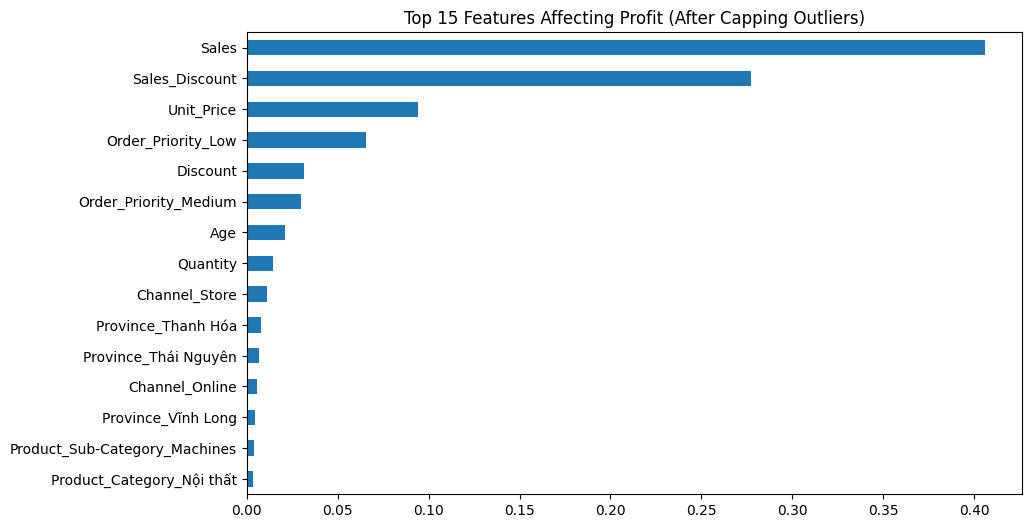

In [437]:
importances = pd.Series(rff.feature_importances_, index=X_corr.columns)

# lấy ra top 15 hoặc 20 để xem
top_features = importances.sort_values(ascending=False).head(15)

#  Vẽ biểu đồ từ kết quả đã lọc
plt.figure(figsize=(10, 6))
top_features.plot(kind='barh')
plt.title("Top 15 Features Affecting Profit (After Capping Outliers)")
plt.gca().invert_yaxis()

Dựa trên biểu đồ Feature Importance, ta xác định được các yếu tố chính chi phối kết quả kinh doanh:
+ Sales (Doanh thu) là yếu tố quan trọng nhất: Với trọng số vượt trội (khoảng 0.4), đây là biến đóng vai trò quyết định đến lợi nhuận. Điều này hoàn toàn hợp lý trong kinh doanh: quy mô bán hàng càng lớn thì tiềm năng lợi nhuận càng cao.
+ Tác động mạnh từ chính sách giá và chiết khấu: * Sales_Discount đứng vị trí thứ 2, cho thấy các chương trình giảm giá ảnh hưởng cực kỳ lớn đến biên lợi nhuận.
+ Unit_Price (Đơn giá) đứng thứ 3. Sự kết hợp giữa đơn giá và mức chiết khấu tạo nên "đòn bẩy" trực tiếp đến dòng tiền lợi nhuận cuối cùng.
+ Cấu trúc đơn hàng (Order Priority): Khác với nhận xét cũ của bạn, Order_Priority_Low có tầm ảnh hưởng lớn hơn đáng kể so với mức Medium. Điều này có thể phản ánh rằng các đơn hàng không gấp thường có quy trình vận hành tối ưu chi phí hơn, hoặc chiếm tỷ trọng lớn trong danh mục sản phẩm có biên lợi nhuận cao.
+ Các yếu tố nhân khẩu học và địa lý có tác động thấp: Các biến như Age, Quantity, hay các khu vực địa lý (Thanh Hóa, Thái Nguyên...) nằm ở nhóm dưới cùng. Điều này chứng tỏ lợi nhuận phụ thuộc chủ yếu vào chiến lược giá và doanh số hơn là đặc điểm vùng miền hay độ tuổi khách hàng cụ thể..